🔧 АНАЛИЗ С ИСПРАВЛЕНИЕМ ФОРМАТА ЧИСЕЛ
Всего найдено файлов: 64
✓ Исправлен файл с запятыми: results_test_fevG10_T4_lCount4_nCount2_run1.txt
✓ Исправлен файл с запятыми: results_test_fevG10_T4_lCount4_nCount2_run3.txt
✓ Исправлен файл с запятыми: results_test_fevG8_T5_lCount2_nCount4_run2.txt
✓ Исправлен файл с запятыми: results_test_fevG8_T5_lCount2_nCount4_run7.txt
✓ Исправлен файл с запятыми: results_test_fevG8_T5_lCount3_nCount3_run5.txt
✓ Исправлен файл с запятыми: results_test_fevG5_T8_lCount4_nCount2_run1.txt
✓ Исправлен файл с запятыми: results_test_fevG5_T8_lCount4_nCount2_run2.txt
✓ Исправлен файл с запятыми: results_test_fevG5_T8_lCount4_nCount2_run4.txt
✓ Исправлен файл с запятыми: results_test_fevG5_T8_lCount4_nCount2_run5.txt
✓ Исправлен файл с запятыми: results_test_fevG5_T8_lCount4_nCount2_run6.txt
✓ Исправлен файл с запятыми: results_test_fevG5_T8_lCount4_nCount2_run7.txt

📊 РЕЗУЛЬТАТЫ АНАЛИЗА (исправлено файлов с запятыми: 63):
status  fevGlobal  T  layerCount  neuronC

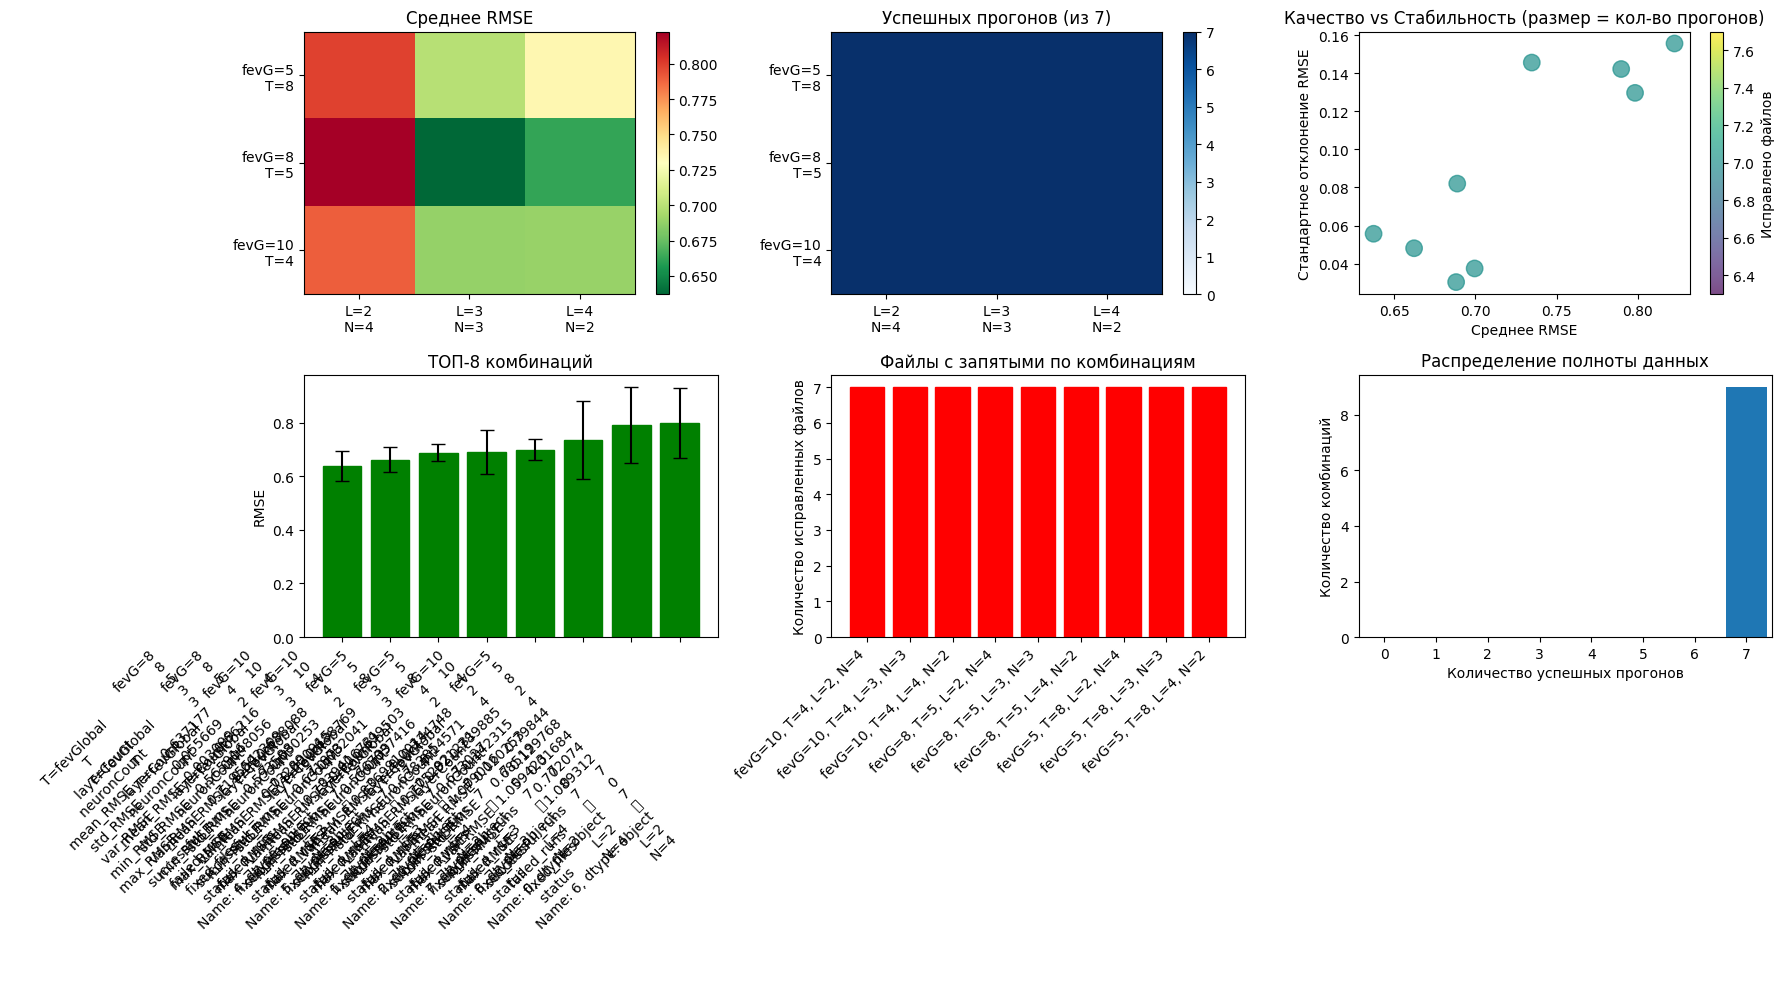


💾 Результаты сохранены в 'analysis_fixed_format.csv'


In [8]:
import os
import numpy as np
import pandas as pd
import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# ============ УКАЖИТЕ ПУТЬ К ФАЙЛАМ ЗДЕСЬ ============
DATA_PATH = "build/results/"  # Измените на путь к вашим файлам
# =====================================================


def load_data_with_comma_support(file_path):
    """Загружает данные, поддерживая оба формата десятичных разделителей"""
    try:
        # Сначала пробуем стандартный способ (с точкой)
        data = np.loadtxt(file_path)
        return data
    except ValueError as e:
        # Если ошибка связана с форматом чисел, пробуем заменить запятые на точки
        if "could not convert string" in str(e):
            try:
                # Читаем файл как текст
                with open(file_path, "r", encoding="utf-8") as f:
                    content = f.read()

                # Заменяем запятые на точки во всем содержимом
                content = content.replace(",", ".")

                # Преобразуем обратно в массив numpy
                from io import StringIO

                data = np.loadtxt(StringIO(content))
                print(f"✓ Исправлен файл с запятыми: {file_path.name}")
                return data
            except Exception as e2:
                print(f"✗ Не удалось исправить файл {file_path.name}: {e2}")
                return None
        else:
            # Другая ошибка
            print(f"✗ Ошибка чтения {file_path.name}: {e}")
            return None
    except Exception as e:
        print(f"✗ Ошибка чтения {file_path.name}: {e}")
        return None


def analyze_fixed_files(data_path):
    """Анализ с поддержкой файлов с запятыми"""

    print("🔧 АНАЛИЗ С ИСПРАВЛЕНИЕМ ФОРМАТА ЧИСЕЛ")
    print("=" * 60)

    # Находим все файлы
    all_files = list(Path(data_path).glob("results_test_*.txt"))
    print(f"Всего найдено файлов: {len(all_files)}")

    # Параметры
    fevGlobal_list = [10, 8, 5]
    T_list = [4, 5, 8]
    layerCount_list = [2, 3, 4]
    neuronCount_list = [4, 3, 2]

    results = []
    fixed_files = []
    failed_files = []

    # Проходим по всем комбинациям параметров
    for ft in range(3):
        fevGlobal = fevGlobal_list[ft]
        T = T_list[ft]

        for ln in range(3):
            layerCount = layerCount_list[ln]
            neuronCount = neuronCount_list[ln]

            rmses = []
            current_fixed = []
            current_failed = []

            # Собираем RMSE для всех прогонов (1-7)
            for runNumber in range(1, 8):
                filename = f"results_test_fevG{fevGlobal}_T{T}_lCount{layerCount}_nCount{neuronCount}_run{runNumber}.txt"
                file_path = Path(data_path) / filename

                if file_path.exists():
                    # Используем функцию с поддержкой запятых
                    data = load_data_with_comma_support(file_path)

                    if data is not None and len(data) > 0:
                        # Проверяем формат данных
                        if data.ndim == 1 and len(data) >= 3:
                            # Одна строка с тремя числами
                            testY = data[1]
                            pred = data[2]
                            rmse = np.sqrt((testY - pred) ** 2)
                            rmses.append(rmse)
                        elif data.ndim == 2 and data.shape[1] >= 3:
                            # Много строк, три колонки
                            testY = data[:, 1]
                            pred = data[:, 2]
                            rmse = np.sqrt(np.mean((testY - pred) ** 2))
                            rmses.append(rmse)
                            current_fixed.append(runNumber)
                        else:
                            current_failed.append(
                                (runNumber, "Некорректный формат данных")
                            )
                    else:
                        current_failed.append(
                            (runNumber, "Не удалось загрузить данные")
                        )
                else:
                    current_failed.append((runNumber, "Файл не найден"))

            if rmses:
                # Вычисляем статистики
                mean_rmse = np.mean(rmses)
                std_rmse = np.std(rmses)
                var_rmse = np.var(rmses)

                results.append(
                    {
                        "fevGlobal": fevGlobal,
                        "T": T,
                        "layerCount": layerCount,
                        "neuronCount": neuronCount,
                        "mean_RMSE": mean_rmse,
                        "std_RMSE": std_rmse,
                        "var_RMSE": var_rmse,
                        "min_RMSE": np.min(rmses),
                        "max_RMSE": np.max(rmses),
                        "successful_runs": len(rmses),
                        "failed_runs": len(current_failed),
                        "fixed_files": len(current_fixed),
                        "status": "✅" if len(rmses) == 7 else "⚠️",
                    }
                )

                if current_fixed:
                    fixed_files.append(
                        {
                            "combo": f"fevG={fevGlobal}, T={T}, L={layerCount}, N={neuronCount}",
                            "fixed_runs": current_fixed,
                            "failed": current_failed,
                        }
                    )

    # Создаем DataFrame с результатами
    df_results = pd.DataFrame(results)

    if len(df_results) > 0:
        # Сортируем по среднему RMSE
        df_results = df_results.sort_values("mean_RMSE")

        # Выводим результаты
        print(
            f"\n📊 РЕЗУЛЬТАТЫ АНАЛИЗА (исправлено файлов с запятыми: {sum(df_results['fixed_files'])}):"
        )
        print("=" * 60)

        # Форматируем вывод
        display_cols = [
            "status",
            "fevGlobal",
            "T",
            "layerCount",
            "neuronCount",
            "mean_RMSE",
            "std_RMSE",
            "successful_runs",
            "fixed_files",
        ]

        print(df_results[display_cols].to_string(index=False))

        # Подробная информация об исправленных файлах
        if fixed_files:
            print(f"\n📝 ИСПРАВЛЕННЫЕ ФАЙЛЫ:")
            print("-" * 40)
            for fix_info in fixed_files:
                print(f"{fix_info['combo']}:")
                if fix_info["fixed_runs"]:
                    print(f"  Исправлены прогоны: {fix_info['fixed_runs']}")
                if fix_info["failed"]:
                    print(f"  Проблемные прогоны: {fix_info['failed']}")
                print()

        # Сводная статистика
        print(f"\n📈 СВОДНАЯ СТАТИСТИКА:")
        print("-" * 40)
        total_files = len(all_files)
        total_successful = df_results["successful_runs"].sum()
        total_fixed = df_results["fixed_files"].sum()

        print(f"Всего файлов: {total_files}")
        print(f"Успешно обработано прогонов: {total_successful}")
        print(f"Исправлено файлов с запятыми: {total_fixed}")
        print(f"Коэффициент успешности: {total_successful/(7*9)*100:.1f}%")

        # Визуализация
        create_visualizations(df_results, fixed_files)

        # Сохраняем результаты
        df_results.to_csv("analysis_fixed_format.csv", index=False)
        print(f"\n💾 Результаты сохранены в 'analysis_fixed_format.csv'")

    return df_results


def create_visualizations(df_results, fixed_files):
    """Создает визуализации результатов"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Heatmap средних RMSE
    pivot_mean = df_results.pivot_table(
        index=["fevGlobal", "T"],
        columns=["layerCount", "neuronCount"],
        values="mean_RMSE",
        fill_value=np.nan,
    )

    ax1 = axes[0, 0]
    im1 = ax1.imshow(pivot_mean.values, cmap="RdYlGn_r", aspect="auto")
    ax1.set_title("Среднее RMSE")
    ax1.set_xticks(range(len(pivot_mean.columns)))
    ax1.set_xticklabels([f"L={c[0]}\nN={c[1]}" for c in pivot_mean.columns], rotation=0)
    ax1.set_yticks(range(len(pivot_mean.index)))
    ax1.set_yticklabels([f"fevG={i[0]}\nT={i[1]}" for i in pivot_mean.index])
    plt.colorbar(im1, ax=ax1)

    # 2. Heatmap успешных прогонов
    pivot_success = df_results.pivot_table(
        index=["fevGlobal", "T"],
        columns=["layerCount", "neuronCount"],
        values="successful_runs",
        fill_value=0,
    )

    ax2 = axes[0, 1]
    im2 = ax2.imshow(pivot_success.values, cmap="Blues", vmin=0, vmax=7, aspect="auto")
    ax2.set_title("Успешных прогонов (из 7)")
    ax2.set_xticks(range(len(pivot_success.columns)))
    ax2.set_xticklabels(
        [f"L={c[0]}\nN={c[1]}" for c in pivot_success.columns], rotation=0
    )
    ax2.set_yticks(range(len(pivot_success.index)))
    ax2.set_yticklabels([f"fevG={i[0]}\nT={i[1]}" for i in pivot_success.index])
    plt.colorbar(im2, ax=ax2)

    # 3. Соотношение RMSE и стабильности
    ax3 = axes[0, 2]
    scatter = ax3.scatter(
        df_results["mean_RMSE"],
        df_results["std_RMSE"],
        s=df_results["successful_runs"] * 20,
        c=df_results["fixed_files"],
        cmap="viridis",
        alpha=0.7,
    )
    ax3.set_xlabel("Среднее RMSE")
    ax3.set_ylabel("Стандартное отклонение RMSE")
    ax3.set_title("Качество vs Стабильность (размер = кол-во прогонов)")
    plt.colorbar(scatter, ax=ax3, label="Исправлено файлов")

    # 4. Лучшие комбинации
    ax4 = axes[1, 0]
    top_n = min(8, len(df_results))
    top_data = df_results.head(top_n).copy()
    top_data["combo"] = top_data.apply(
        lambda x: f"fevG={x.fevGlobal}\nT={x.T}\nL={x.layerCount}\nN={x.neuronCount}",
        axis=1,
    )

    x_pos = range(len(top_data))
    bars = ax4.bar(x_pos, top_data["mean_RMSE"])

    # Цвета в зависимости от полноты данных
    for i, (idx, row) in enumerate(top_data.iterrows()):
        if row["successful_runs"] == 7:
            bars[i].set_color("green")
        elif row["successful_runs"] >= 5:
            bars[i].set_color("orange")
        else:
            bars[i].set_color("red")

    ax4.errorbar(
        x_pos,
        top_data["mean_RMSE"],
        yerr=top_data["std_RMSE"],
        fmt="none",
        color="black",
        capsize=5,
    )

    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(top_data["combo"], rotation=45, ha="right")
    ax4.set_ylabel("RMSE")
    ax4.set_title(f"ТОП-{top_n} комбинаций")

    # 5. Распределение исправленных файлов
    ax5 = axes[1, 1]
    if fixed_files:
        fix_counts = [len(fix["fixed_runs"]) for fix in fixed_files]
        combo_labels = [fix["combo"] for fix in fixed_files]

        bars_fix = ax5.bar(range(len(fix_counts)), fix_counts)
        ax5.set_xticks(range(len(fix_counts)))
        ax5.set_xticklabels(combo_labels, rotation=45, ha="right")
        ax5.set_ylabel("Количество исправленных файлов")
        ax5.set_title("Файлы с запятыми по комбинациям")

        # Подсветим те, где были исправлены все 7
        for i, count in enumerate(fix_counts):
            if count == 7:
                bars_fix[i].set_color("red")

    # 6. Общая статистика успешности
    ax6 = axes[1, 2]
    success_counts = df_results["successful_runs"].value_counts().sort_index()
    ax6.bar(success_counts.index, success_counts.values)
    ax6.set_xlabel("Количество успешных прогонов")
    ax6.set_ylabel("Количество комбинаций")
    ax6.set_title("Распределение полноты данных")
    ax6.set_xticks(range(0, 8))
    ax6.set_xlim(-0.5, 7.5)

    plt.tight_layout()
    plt.show()


# Запускаем анализ с исправлением
if __name__ == "__main__":
    if not os.path.exists(DATA_PATH):
        print(f"❌ Ошибка: путь '{DATA_PATH}' не существует!")
    else:
        results_df = analyze_fixed_files(DATA_PATH)

✅ Найдено 9 комбинаций с медианными прогонами
📊 Построение графиков для каждой комбинации:

График 1: fevG=10, T=4, L=2, N=4


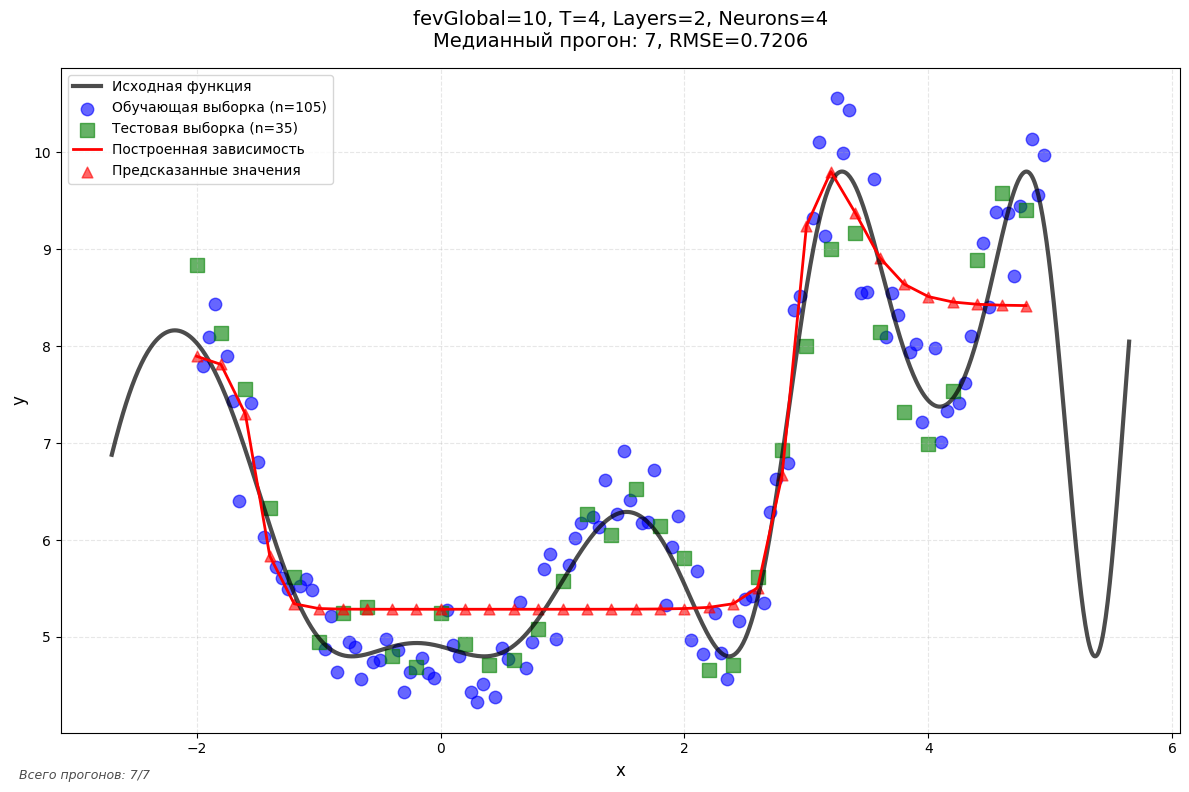


График 2: fevG=10, T=4, L=3, N=3


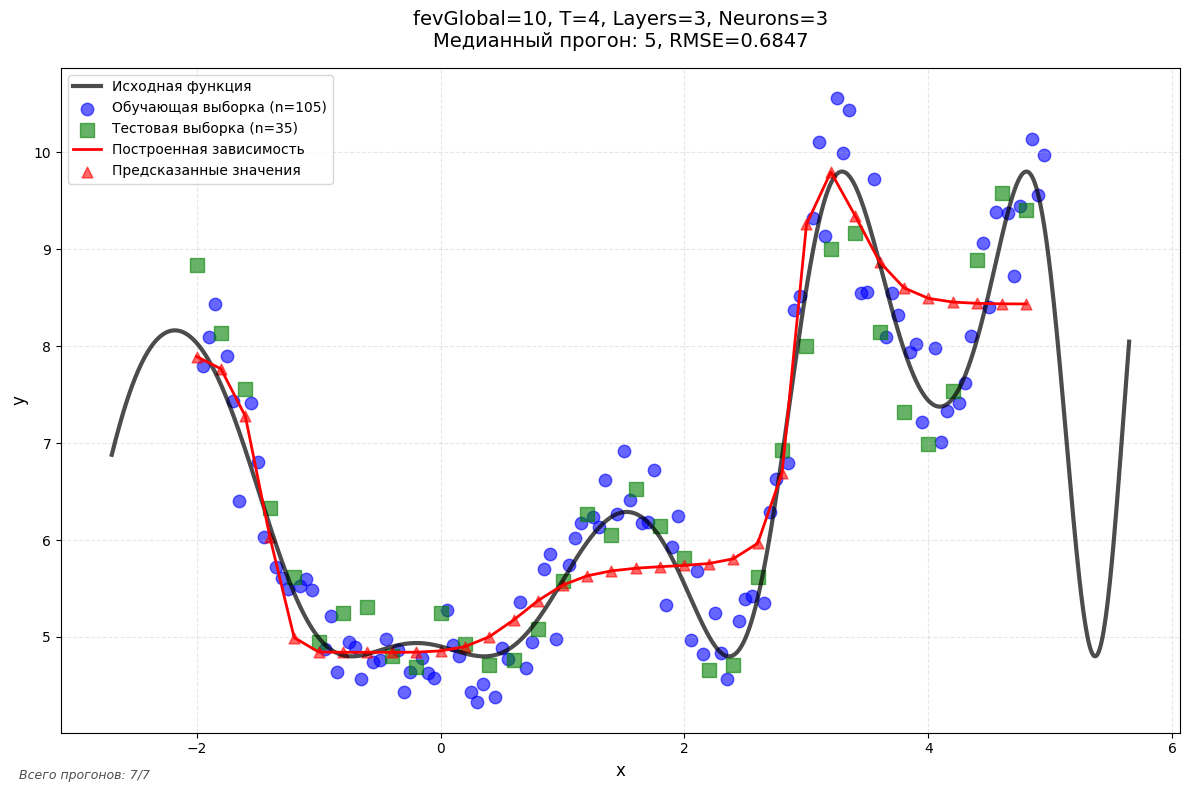


График 3: fevG=10, T=4, L=4, N=2


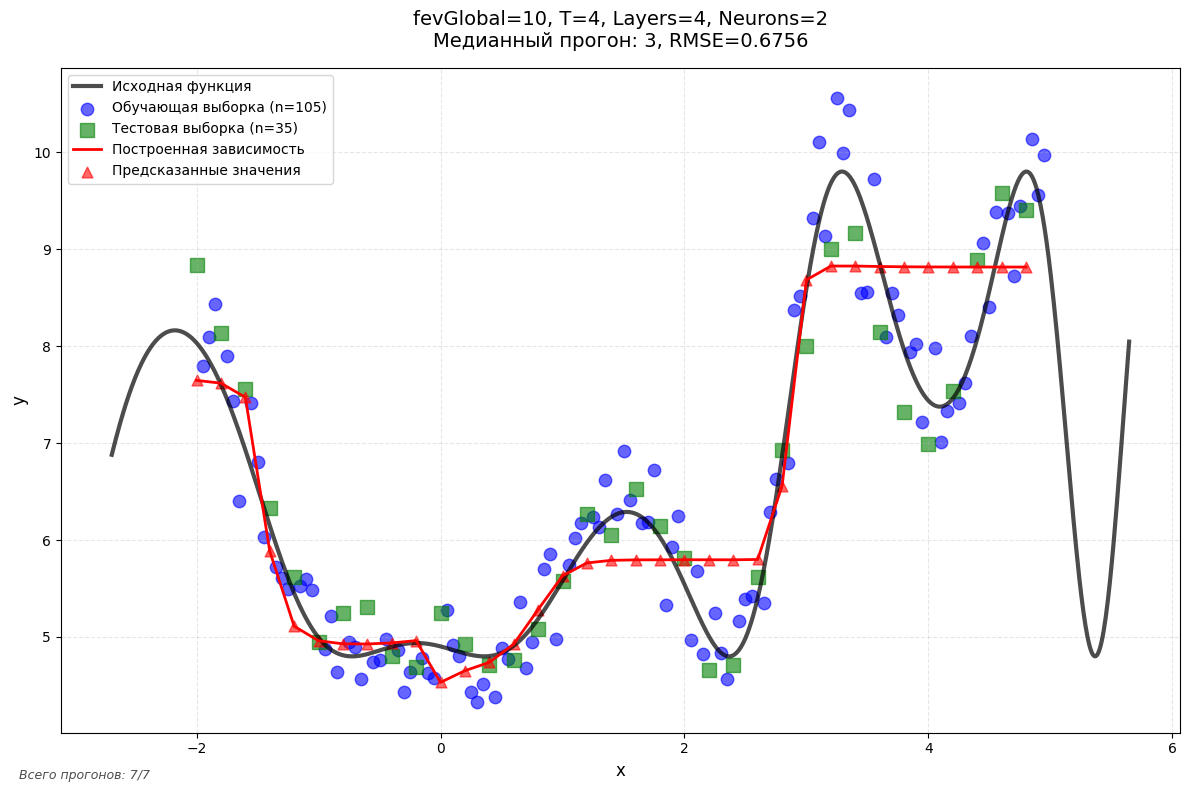


График 4: fevG=8, T=5, L=2, N=4


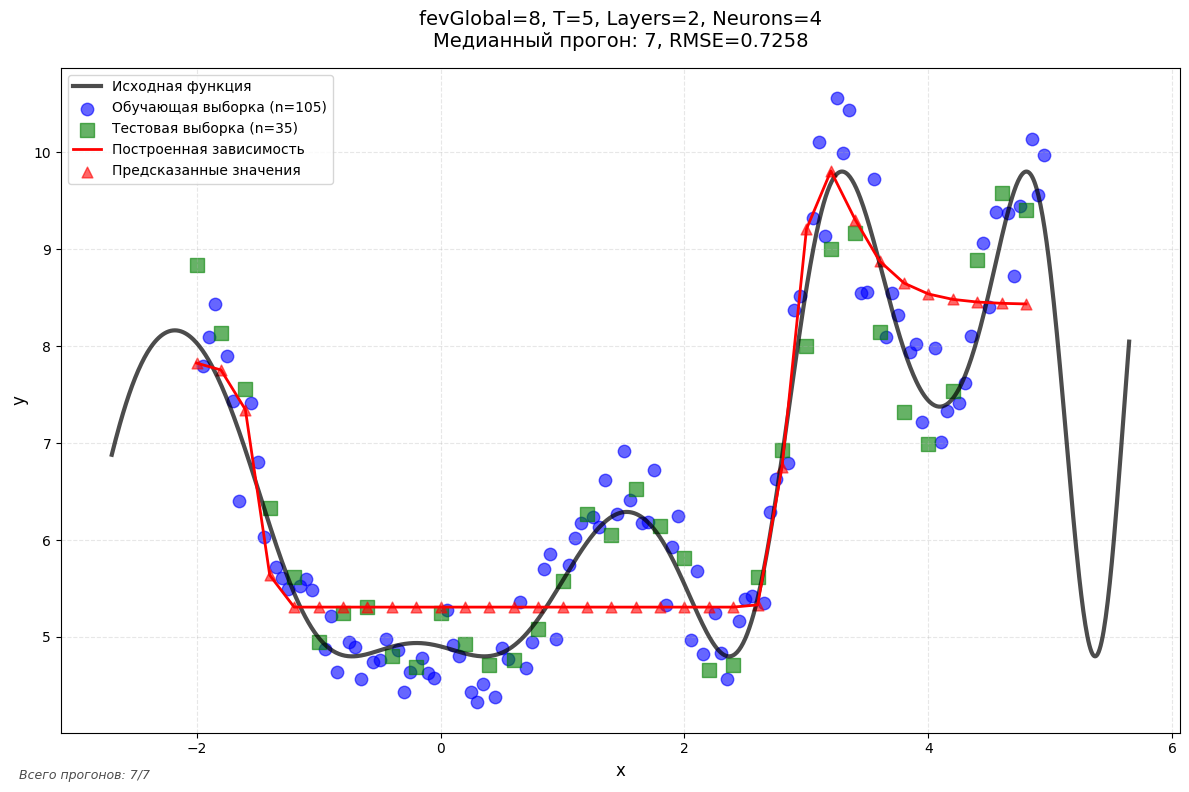


График 5: fevG=8, T=5, L=3, N=3


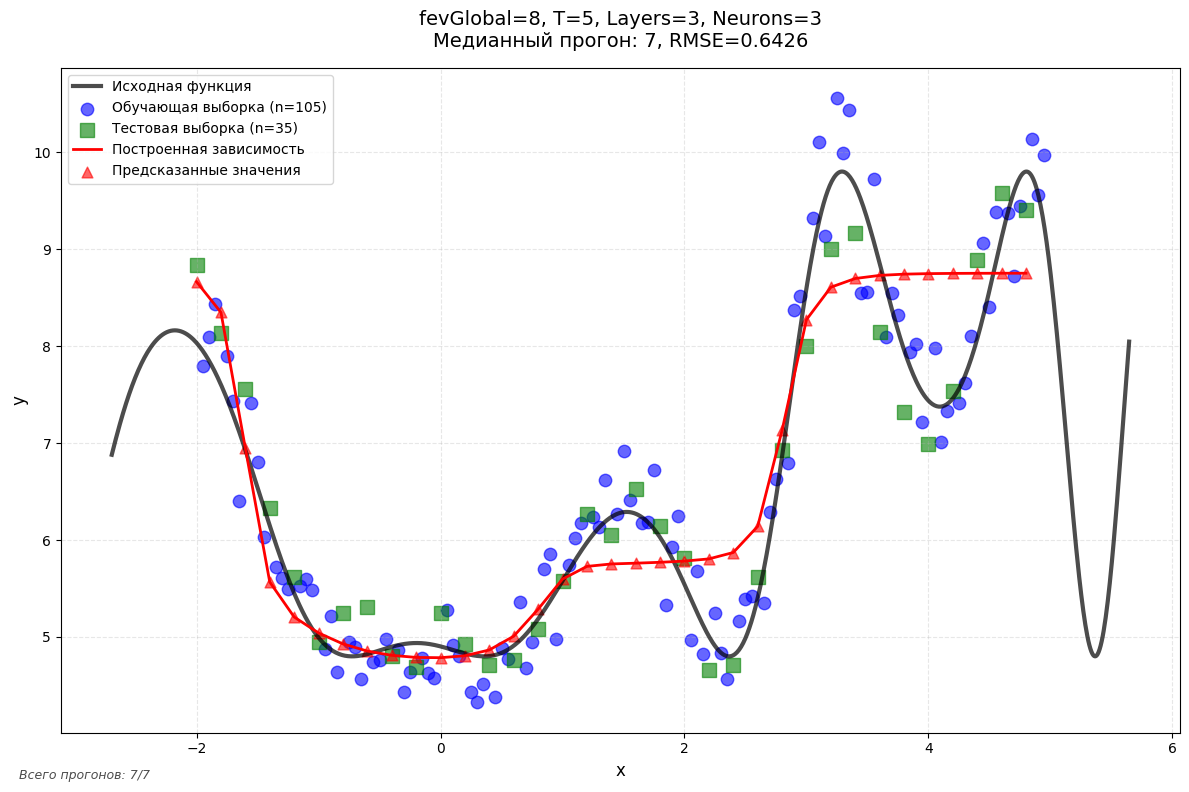


График 6: fevG=8, T=5, L=4, N=2


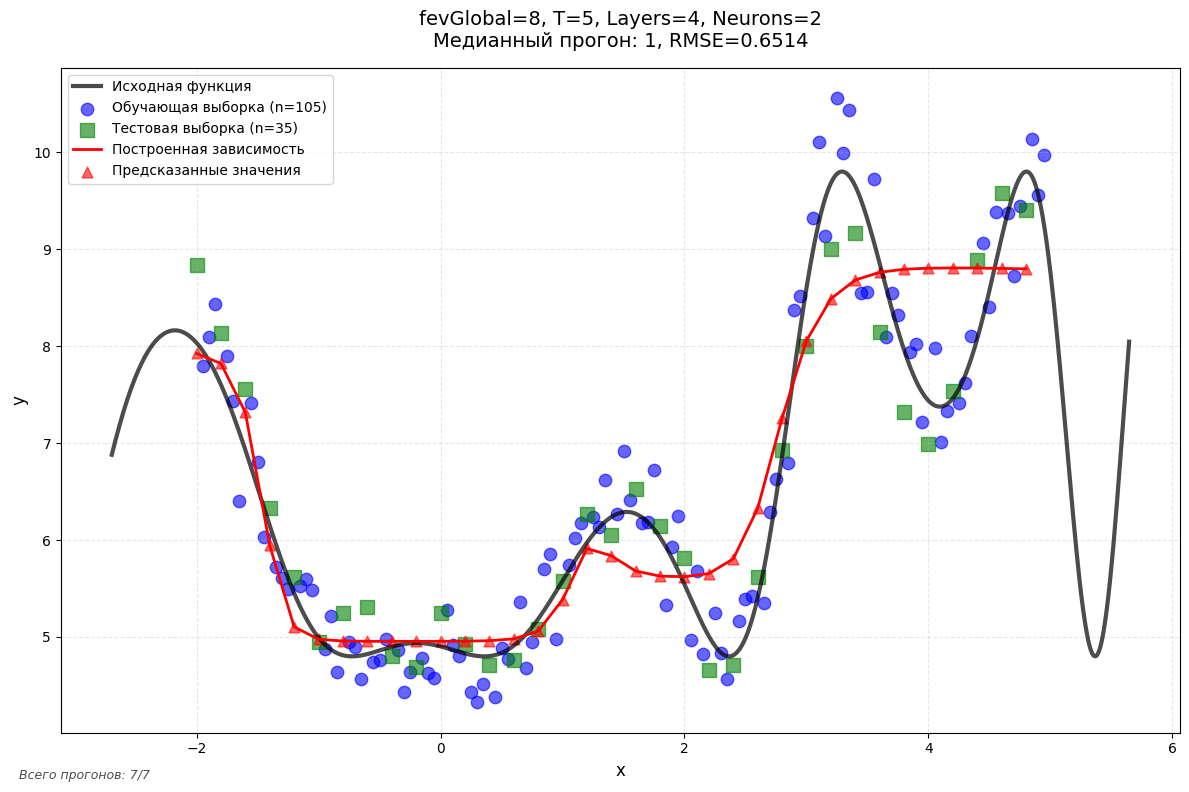


График 7: fevG=5, T=8, L=2, N=4


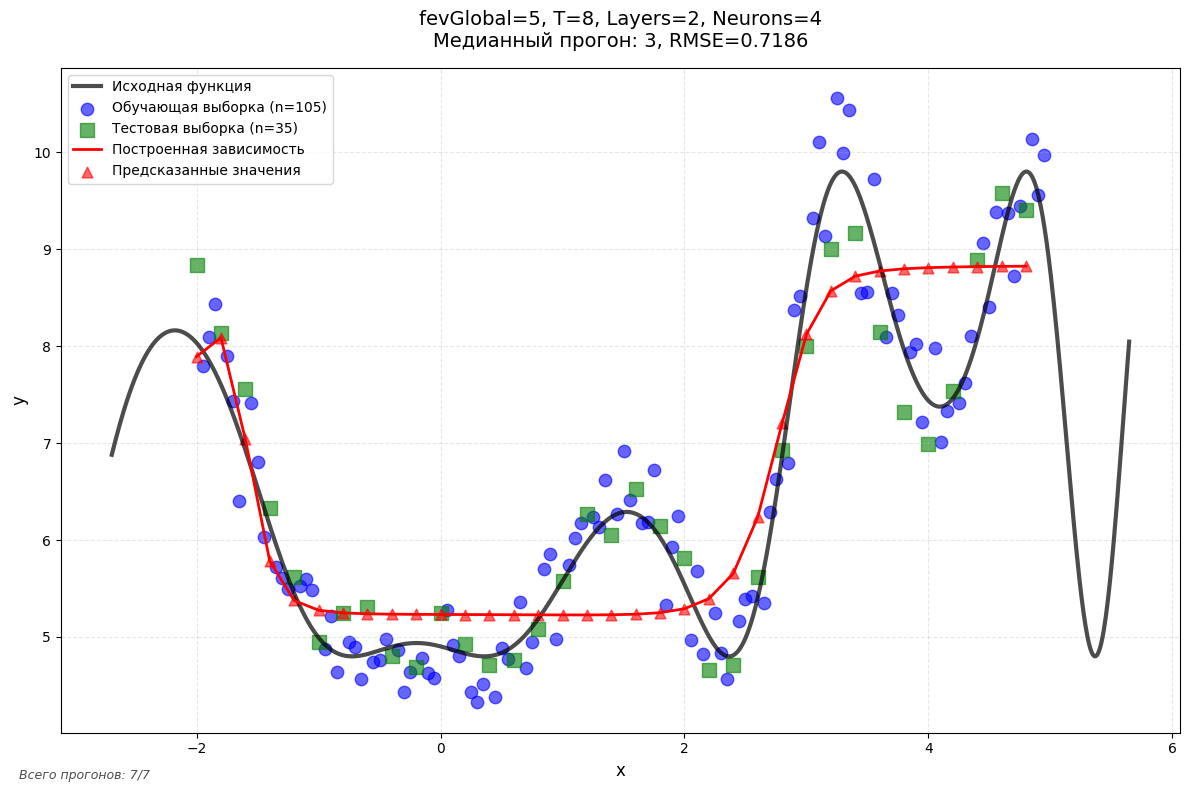


График 8: fevG=5, T=8, L=3, N=3


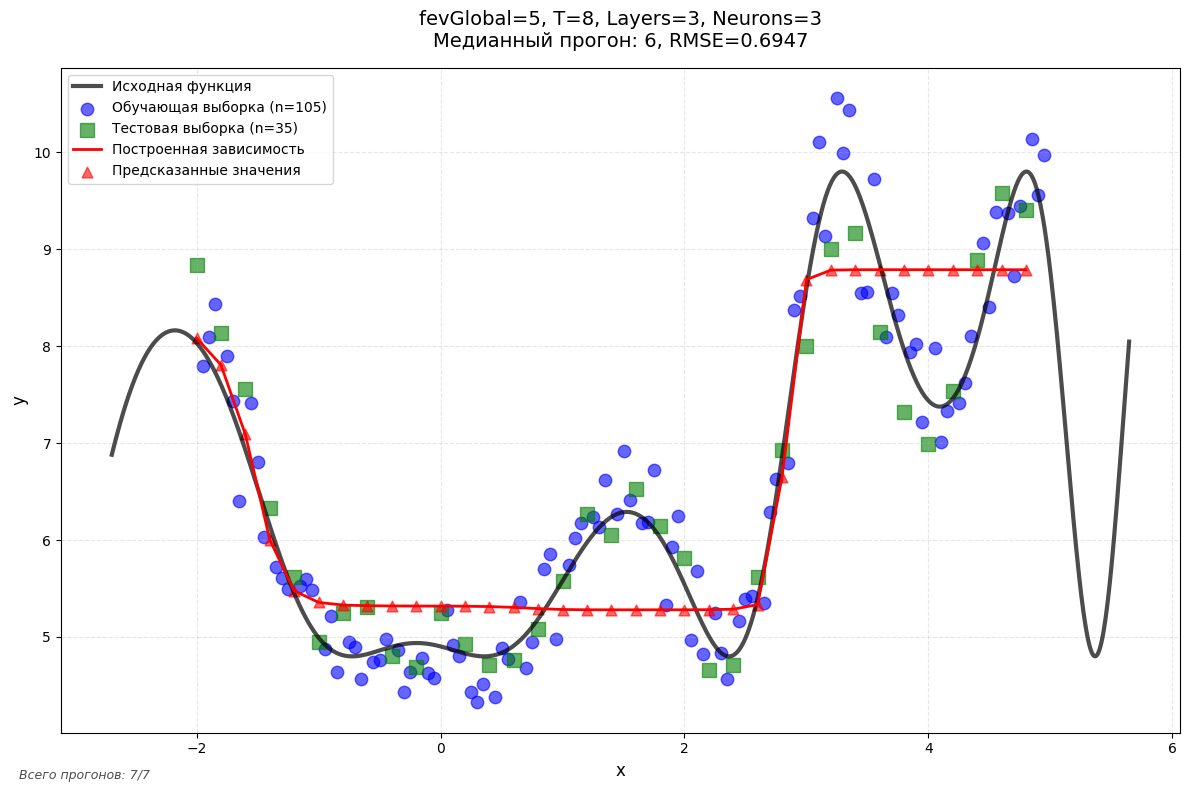


График 9: fevG=5, T=8, L=4, N=2


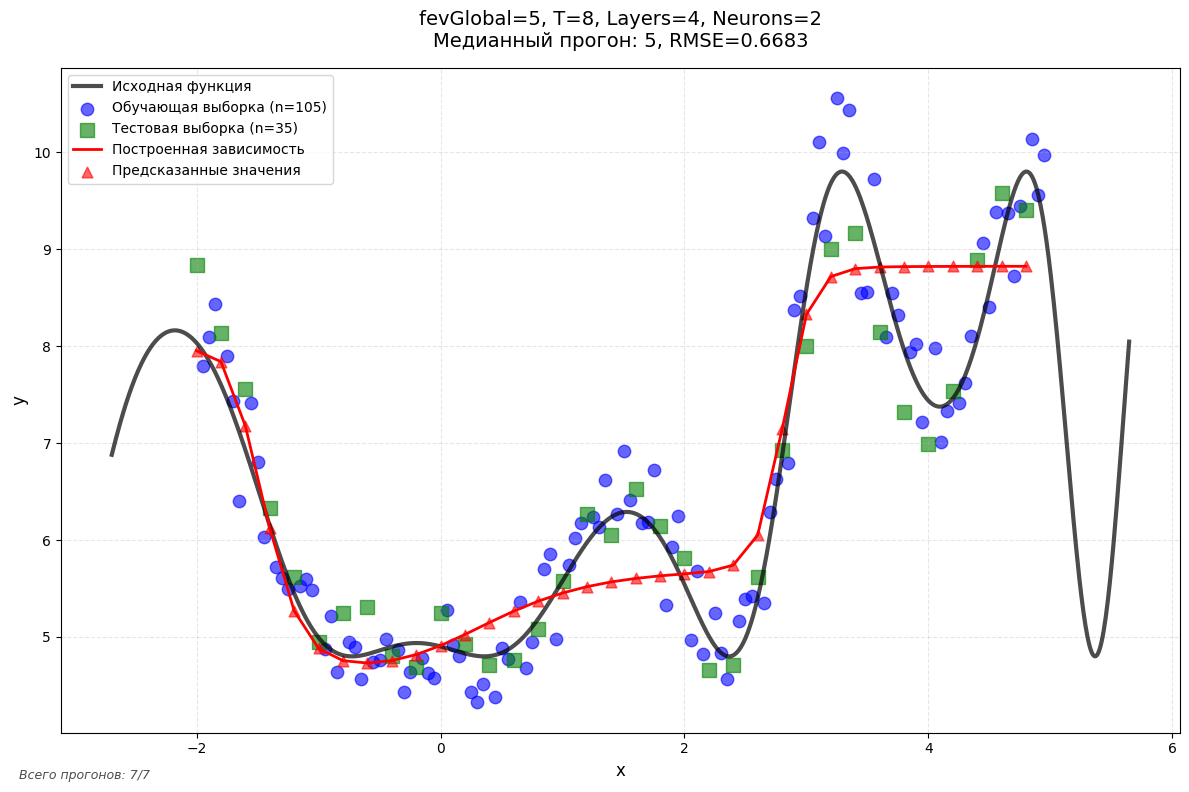


💾 Информация сохранена в 'median_runs_jupyter.csv'


In [10]:
# Ячейка 1: Импорт и настройка
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
from io import StringIO

# Укажите путь к данным
DATA_PATH = "build/results/"  # Измените на ваш путь


# Исходная функция
def original_function(x):
    return 2.5 * np.sin(1.1 * np.cos(1.1 * x + 2) * x + 5) + 7.3


# Ячейка 2: Функция загрузки данных
def load_data_with_comma_support(file_path):
    """Загружает данные, поддерживая оба формата десятичных разделителей"""
    try:
        data = np.loadtxt(file_path)
        return data
    except ValueError as e:
        if "could not convert string" in str(e):
            try:
                with open(file_path, "r", encoding="utf-8") as f:
                    content = f.read()
                content = content.replace(",", ".")
                data = np.loadtxt(StringIO(content))
                return data
            except:
                return None
        return None
    except:
        return None


# Ячейка 3: Нахождение всех медианных прогонов
# Параметры из вашего кода
fevGlobal_list = [10, 8, 5]
T_list = [4, 5, 8]
layerCount_list = [2, 3, 4]
neuronCount_list = [4, 3, 2]

median_runs_info = []

# Проходим по всем комбинациям параметров
for ft in range(3):
    fevGlobal = fevGlobal_list[ft]
    T = T_list[ft]

    for ln in range(3):
        layerCount = layerCount_list[ln]
        neuronCount = neuronCount_list[ln]

        rmses = []
        run_numbers = []

        # Собираем RMSE для всех прогонов (1-7)
        for runNumber in range(1, 8):
            test_filename = f"results_test_fevG{fevGlobal}_T{T}_lCount{layerCount}_nCount{neuronCount}_run{runNumber}.txt"
            test_path = Path(DATA_PATH) / test_filename

            if test_path.exists():
                test_data = load_data_with_comma_support(test_path)
                if test_data is not None and len(test_data) > 0:
                    if test_data.ndim == 2 and test_data.shape[1] >= 3:
                        testY = test_data[:, 1]
                        pred = test_data[:, 2]
                        rmse = np.sqrt(np.mean((testY - pred) ** 2))
                        rmses.append(rmse)
                        run_numbers.append(runNumber)

        # Находим медианный прогон
        if rmses:
            sorted_indices = np.argsort(rmses)
            sorted_rmses = np.array(rmses)[sorted_indices]
            sorted_runs = np.array(run_numbers)[sorted_indices]

            median_idx = len(sorted_rmses) // 2
            median_run = sorted_runs[median_idx]
            median_rmse = sorted_rmses[median_idx]

            median_runs_info.append(
                {
                    "fevGlobal": fevGlobal,
                    "T": T,
                    "layerCount": layerCount,
                    "neuronCount": neuronCount,
                    "median_run": median_run,
                    "median_rmse": median_rmse,
                    "total_runs": len(rmses),
                }
            )

print(f"✅ Найдено {len(median_runs_info)} комбинаций с медианными прогонами")


# Ячейка 4: Функция построения графика для одной комбинации
def plot_single_combo(combo_info):
    """Строит график для одной комбинации параметров"""

    fevGlobal = combo_info["fevGlobal"]
    T = combo_info["T"]
    layerCount = combo_info["layerCount"]
    neuronCount = combo_info["neuronCount"]
    median_run = combo_info["median_run"]

    # Загружаем данные
    test_filename = f"results_test_fevG{fevGlobal}_T{T}_lCount{layerCount}_nCount{neuronCount}_run{median_run}.txt"
    train_filename = f"results_train_fevG{fevGlobal}_T{T}_lCount{layerCount}_nCount{neuronCount}_run{median_run}.txt"

    test_data = load_data_with_comma_support(Path(DATA_PATH) / test_filename)
    train_data = load_data_with_comma_support(Path(DATA_PATH) / train_filename)

    if test_data is None or train_data is None:
        print(f"❌ Не удалось загрузить данные для этой комбинации")
        return

    # Извлекаем данные
    if test_data.ndim == 1:
        testX, testY, test_pred = test_data[0], test_data[1], test_data[2]
    else:
        testX, testY, test_pred = test_data[:, 0], test_data[:, 1], test_data[:, 2]

    if train_data.ndim == 1:
        trainX, trainY, train_pred = train_data[0], train_data[1], train_data[2]
    else:
        trainX, trainY, train_pred = (
            train_data[:, 0],
            train_data[:, 1],
            train_data[:, 2],
        )

    # Определяем диапазон для построения
    all_x = np.concatenate([trainX.flatten(), testX.flatten()])
    x_min, x_max = all_x.min(), all_x.max()
    x_range = x_max - x_min
    x_min_plot = x_min - 0.1 * x_range
    x_max_plot = x_max + 0.1 * x_range

    # Создаем точки для исходной функции
    x_plot = np.linspace(x_min_plot, x_max_plot, 1000)
    y_plot = original_function(x_plot)

    # Сортируем для построения линии предсказаний
    sorted_idx = np.argsort(testX)
    testX_sorted = testX[sorted_idx]
    test_pred_sorted = test_pred[sorted_idx]

    # Создаем график
    fig, ax = plt.subplots(figsize=(12, 8))

    # Исходная функция
    ax.plot(x_plot, y_plot, "k-", linewidth=3, alpha=0.7, label="Исходная функция")

    # Обучающая выборка
    ax.scatter(
        trainX,
        trainY,
        color="blue",
        s=80,
        alpha=0.6,
        label=f"Обучающая выборка (n={len(trainX)})",
    )

    # Тестовая выборка
    ax.scatter(
        testX,
        testY,
        color="green",
        s=100,
        alpha=0.6,
        marker="s",
        label=f"Тестовая выборка (n={len(testX)})",
    )

    # Построенная зависимость
    ax.plot(
        testX_sorted,
        test_pred_sorted,
        "r-",
        linewidth=2,
        label="Построенная зависимость",
    )
    ax.scatter(
        testX,
        test_pred,
        color="red",
        s=60,
        alpha=0.6,
        marker="^",
        label="Предсказанные значения",
    )

    # Настройки графика
    ax.set_title(
        f"fevGlobal={fevGlobal}, T={T}, Layers={layerCount}, Neurons={neuronCount}\n"
        f'Медианный прогон: {median_run}, RMSE={combo_info["median_rmse"]:.4f}',
        fontsize=14,
        pad=15,
    )
    ax.set_xlabel("x", fontsize=12)
    ax.set_ylabel("y", fontsize=12)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(loc="best", fontsize=10)

    # Добавляем подпись с информацией
    plt.figtext(
        0.02,
        0.02,
        f'Всего прогонов: {combo_info["total_runs"]}/7',
        fontsize=9,
        style="italic",
        alpha=0.7,
    )

    plt.tight_layout()
    plt.show()


# Ячейка 5: Построение всех графиков по отдельности
print("📊 Построение графиков для каждой комбинации:")
print("=" * 50)

for i, combo in enumerate(median_runs_info, 1):
    print(
        f"\nГрафик {i}: fevG={combo['fevGlobal']}, T={combo['T']}, "
        f"L={combo['layerCount']}, N={combo['neuronCount']}"
    )
    plot_single_combo(combo)

# Сохраняем информацию
df_median = pd.DataFrame(median_runs_info)
df_median.to_csv("median_runs_jupyter.csv", index=False)
print(f"\n💾 Информация сохранена в 'median_runs_jupyter.csv'")